In [1]:
import sys 
from pathlib import Path

import numpy as np 
import torch 
import seaborn as sns 
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer, 
    DataCollatorWithPadding,
    Trainer, 
    TrainingArguments,
)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score, precision_recall_curve, auc

c:\Users\cola0\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ROOT = Path.cwd().resolve().parent

if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from project_paths import get_paths

paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("DATA_DIR:", DATA_DIR)
print("CKPT_DIR:", CKPT_DIR)

Device: cuda
DATA_DIR: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\data\processed
CKPT_DIR: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints


In [3]:
TEACHER_CKPT = CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000"
STUDENT_CKPT = CKPT_DIR / "tinybert_phase2" / "checkpoint-13000"

TEACHER_THRESHOLD = 0.52 
STUDENT_THRESHOLD = 0.5

print("Teacher ckpt:", TEACHER_CKPT)
print("Student ckpt:", STUDENT_CKPT)

Teacher ckpt: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints\bert_teacher_finetuned\checkpoint-18000
Student ckpt: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints\tinybert_phase2\checkpoint-13000


In [4]:
test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]

print("Test size:", len(test_ds))
print("Columns:", test_ds.column_names)

def ensure_labels_column(ds):
    if "labels" in ds.column_names:
        return ds
    if "label" in ds.column_names:
        return ds.rename_column("label", "labels")
    raise ValueError("Il dataset deve contenere una colonna 'labels' o 'label'.")

test_ds = ensure_labels_column(test_ds)
print("Columns after check:", test_ds.column_names)

Test size: 31344
Columns: ['review_id', 'movie_id', 'text', 'label', 'input_ids', 'attention_mask', 'token_type_ids']
Columns after check: ['review_id', 'movie_id', 'text', 'labels', 'input_ids', 'attention_mask', 'token_type_ids']


In [5]:
sample = test_ds[0]
print("Chiavi sample:", sample.keys())
print("Prime 20 input_ids:", sample["input_ids"][:20])
print("Prime 20 attention_mask:", sample["attention_mask"][:20])
print("Label:", sample["labels"])

Chiavi sample: dict_keys(['review_id', 'movie_id', 'text', 'labels', 'input_ids', 'attention_mask', 'token_type_ids'])
Prime 20 input_ids: [101, 1045, 2052, 2031, 2776, 5407, 2105, 2000, 3666, 2023, 2143, 1010, 2021, 2026, 10628, 2001, 14255, 4226, 2094, 2043]
Prime 20 attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Label: 1


In [6]:
def make_infer_trainer(model_path, per_device_eval_batch_size=32):
    tokenizer = AutoTokenizer.from_pretrained(str(model_path), use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(str(model_path)).to(device)
    model.eval()
    collator = DataCollatorWithPadding(tokenizer=tokenizer)

    args = TrainingArguments(
        output_dir=str(paths.checkpoints / "_tmp_inference"),
        per_device_eval_batch_size=per_device_eval_batch_size,
        dataloader_num_workers=2,
        report_to="none",
        fp16 = False,
    )

    trainer = Trainer(
        model=model,
        args=args,
        data_collator=collator,
        tokenizer=tokenizer,
    )

    return trainer, tokenizer

In [7]:
def predict_probs_and_preds(trainer, ds, threshold):
    pred_out = trainer.predict(ds)

    logits = torch.tensor(pred_out.predictions)  # shape [N, 2]
    probs = torch.softmax(logits, dim=-1).cpu().numpy()[:, 1]  # P(classe=1)
    y_true = pred_out.label_ids.astype(int)
    y_pred = (probs >= threshold).astype(int)

    return y_true, probs, y_pred

In [8]:
#TEACHER_CKPT = "google-bert/bert-base-uncased"
#STUDENT_CKPT = "huawei-noah/TinyBERT_General_4L_312D"

teacher_trainer, teacher_tokenizer = make_infer_trainer(TEACHER_CKPT, per_device_eval_batch_size=32)
student_trainer, student_tokenizer = make_infer_trainer(STUDENT_CKPT, per_device_eval_batch_size=32)

y_true_teacher, probs_teacher, y_pred_teacher = predict_probs_and_preds(teacher_trainer, test_ds, TEACHER_THRESHOLD)

y_true_student, probs_student, y_pred_student = predict_probs_and_preds(student_trainer, test_ds, STUDENT_THRESHOLD)

assert np.array_equal(y_true_teacher, y_true_student), "Le label del test set non coincidono tra teacher e student!"
y_true = y_true_teacher

print("Teacher pred positive rate:", y_pred_teacher.mean())
print("Student pred positive rate:", y_pred_student.mean())

C:\Users\cola0\AppData\Local\Temp\ipykernel_20004\2256893836.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Teacher pred positive rate: 0.30056789178152116
Student pred positive rate: 0.2865301174068402


In [9]:
f1_teacher = f1_score(y_true, y_pred_teacher)
print(f"F1 score teacher: {f1_teacher:.4f}")
f1_student = f1_score(y_true, y_pred_student)
print(f"F1 score student: {f1_student:.4f}")

auc_teacher = roc_auc_score(y_true, probs_teacher)
auc_student = roc_auc_score(y_true, probs_student)  
print(f"AUC teacher: {auc_teacher:.4f}")
print(f"AUC student: {auc_student:.4f}")

F1 score teacher: 0.5964
F1 score student: 0.5735
AUC teacher: 0.8181
AUC student: 0.8036


In [10]:
cm_teacher = confusion_matrix(y_true, y_pred_teacher, labels=[0, 1])
cm_student = confusion_matrix(y_true, y_pred_student, labels=[0, 1])

print("Confusion matrix teacher:\n", cm_teacher)
print("Confusion matrix student:\n", cm_student)

Confusion matrix teacher:
 [[19022  4185]
 [ 2901  5236]]
Confusion matrix student:
 [[19135  4072]
 [ 3228  4909]]


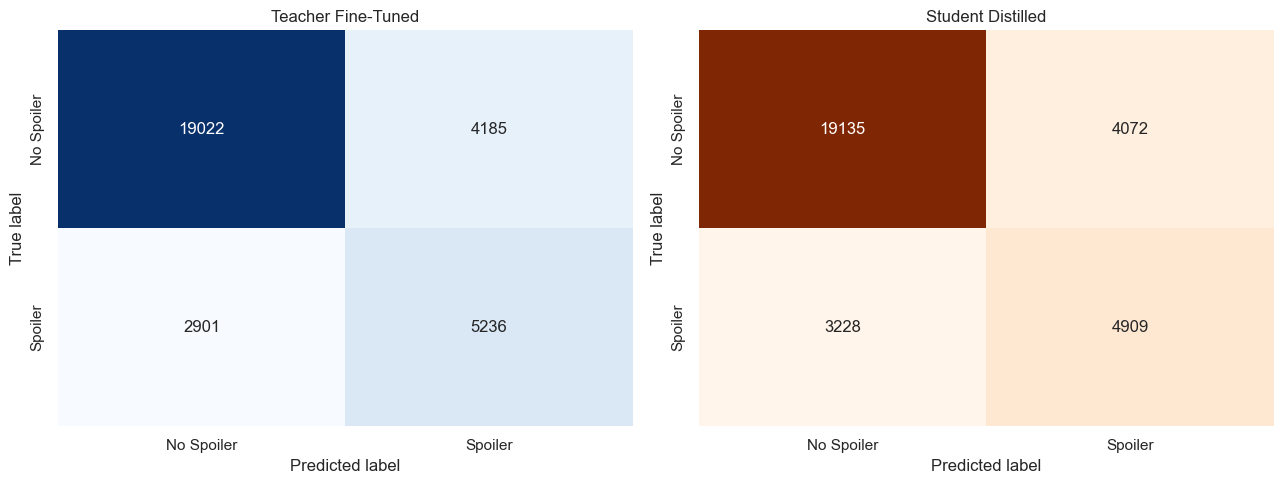

In [13]:
sns.set_theme(style="white", context="notebook")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

label_names = ["No Spoiler", "Spoiler"]

# Teacher (Blu/Azzurro)
sns.heatmap(
    cm_teacher,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=label_names,
    yticklabels=label_names,
    ax=axes[0]
)
axes[0].set_title(f"Teacher Fine-Tuned")
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")

# Student (Arancione)
sns.heatmap(
    cm_student,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    xticklabels=label_names,
    yticklabels=label_names,
    ax=axes[1]
)
axes[1].set_title(f"Student Distilled")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")

plt.tight_layout()
plt.show()

In [12]:
FIG_DIR = paths.root / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig_path = FIG_DIR / "confusion_matrices_teacher_vs_student_test.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved:", fig_path)

Saved: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\figures\confusion_matrices_teacher_vs_student_test.png
